In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Selected 37 significant features based on correlation > 0.05.
NaN counts in significant_features before VWAP/CPD:
X21     0
X332    0
X748    0
X181    0
X614    0
X23     0
X137    0
X198    0
X40     0
X359    0
X28     0
X772    0
X759    0
X183    0
X320    0
X22     0
X507    0
X27     0
X175    0
X179    0
X314    0
X26     0
X197    0
X18     0
X29     0
X508    0
X338    0
X754    0
X20     0
X773    0
X186    0
X756    0
X326    0
X169    0
X173    0
X19     0
X752    0
dtype: int64
Label distribution before filtering:
count    525886.000000
mean          0.036126
std           1.009776
min         -24.416615
25%          -0.381586
50%           0.016261
75%           0.434137
max          20.740271
Name: label, dtype: float64
Label NaNs: 0
Label infinities: 0


/tmp/ipykernel_36/3077209858.py:67: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vwap'] = df['vwap'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_36/3077209858.py:67: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vwap'] = df['vwap'].fillna(method='ffill').fillna(method='bfill')


Selected 34 features after get_feature_set: ['X21', 'X332', 'X748', 'X614', 'X23', 'vwap_mom_5', 'vwap_cpd_21', 'vwap_mom_10', 'X359', 'X28', 'X772', 'X759', 'X183', 'X320', 'X22', 'X507', 'X27', 'X314', 'X26', 'X18', 'X29', 'X508', 'X338', 'X754', 'X20', 'vwap_mom_21', 'X773', 'vwap_cpd_10', 'X186', 'X756', 'X326', 'vwap_cpd_5', 'X19', 'X752']
Index dtype: datetime64[ns]
Index min: 1970-01-01 00:00:00, max: 1970-01-01 00:00:00.000525885
Rows before filtering: 525886
Rows after label filtering: 524182
Weight NaNs: 0
Weight summary:
count    524182.000000
mean          0.638079
std           0.763142
min           0.002003
25%           0.180735
50%           0.408966
75%           0.808941
max           9.995984
Name: weight, dtype: float64
Feature NaNs:
X21            0
X332           0
X748           0
X614           0
X23            0
vwap_mom_5     0
vwap_cpd_21    0
vwap_mom_10    0
X359           0
X28            0
X772           0
X759           0
X183           0
X320          

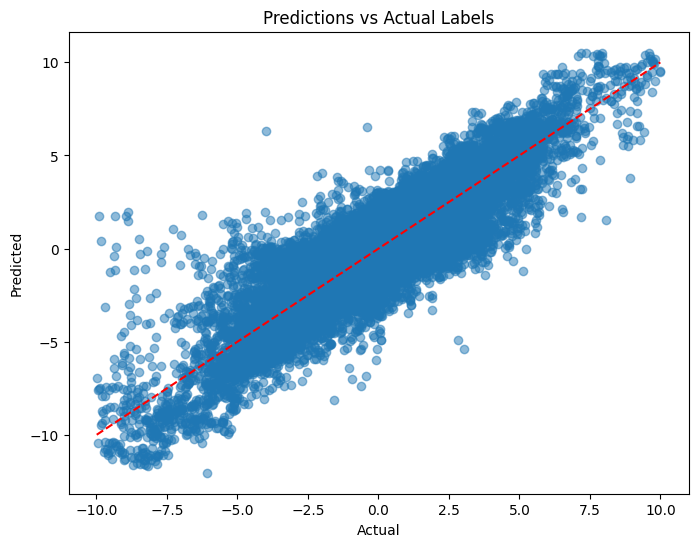

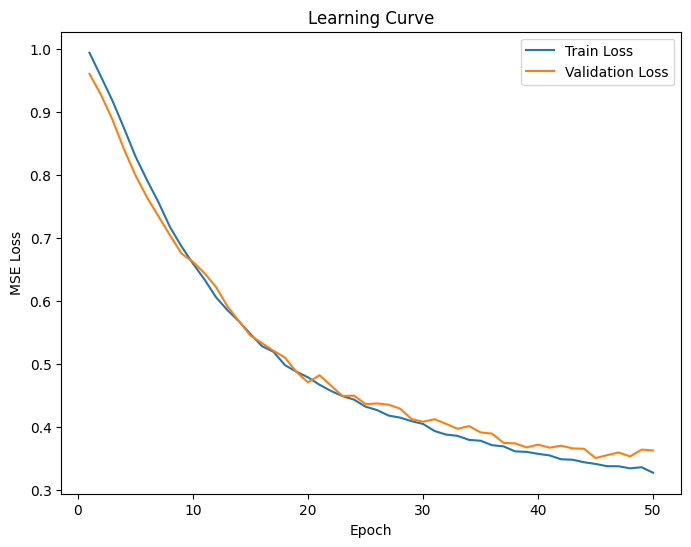

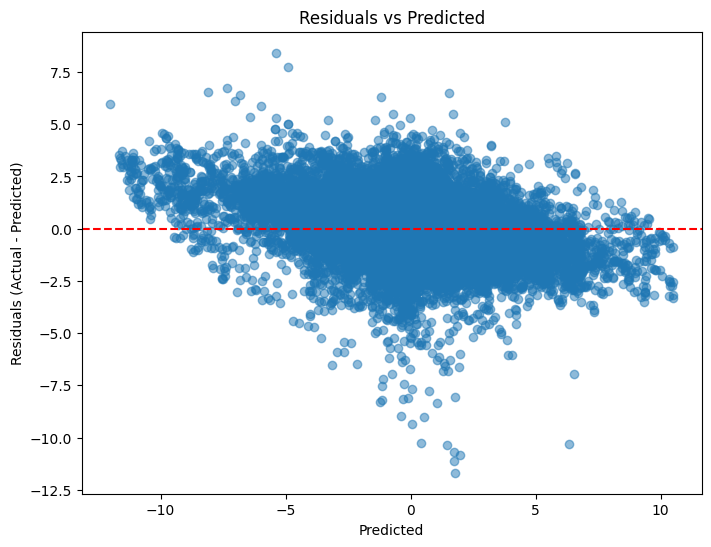

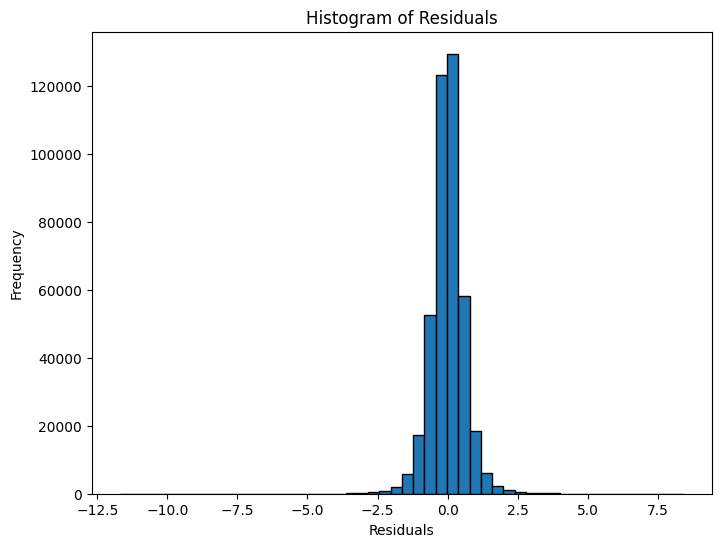

Submission saved to /kaggle/working/submission_momentum_vwap.csv


0

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pyarrow.parquet as pq
import gc
import sys
import os
import matplotlib.pyplot as plt

# Add path to custom feature selection module (simplified version)
sys.path.append('/kaggle/working/crypto_market_prediction')
# Simulate get_feature_set
def get_feature_set(features, corr_thresh=0.99, vif_tresh=100, mi_tresh=0.05):
    return [f for f in features if correlations.get(f, 0) > mi_tresh]

# --- Weighted Pearson Correlation Coefficient ---
def weighted_pearsonr(x, y, weights=None):
    if weights is None:
        weights = np.ones(len(x))
    valid_idx = np.isfinite(x) & np.isfinite(y) & np.isfinite(weights)
    x, y, weights = x[valid_idx], y[valid_idx], weights[valid_idx]
    if len(x) == 0:
        return np.nan, np.nan
    sum_weights = np.sum(weights)
    x_mean = np.sum(weights * x) / sum_weights
    y_mean = np.sum(weights * y) / sum_weights
    cov = np.sum(weights * (x - x_mean) * (y - y_mean))
    x_var = np.sum(weights * (x - x_mean)**2)
    y_var = np.sum(weights * (y - y_mean)**2)
    if x_var == 0 or y_var == 0:
        return 0.0, np.nan
    x_std = np.sqrt(x_var)
    y_std = np.sqrt(y_var)
    correlation = cov / (x_std * y_std)
    return correlation, np.nan

# --- Changepoint Detection (Simple CUSUM-based) ---
def cusum_changepoint_detection(series, window=21, threshold=3.0):
    series = series.fillna(series.mean()).values
    cusum = np.zeros(len(series))
    mean = np.mean(series[:window])
    std = np.std(series[:window]) + 1e-6
    for i in range(1, len(series)):
        drift = (series[i] - mean) / std
        cusum[i] = max(0, cusum[i-1] + drift)
        if i >= window:
            mean = np.mean(series[i-window:i])
            std = np.std(series[i-window:i]) + 1e-6
        if cusum[i] > threshold:
            cusum[i] = 0
    severity = np.clip(cusum, 0, threshold) / threshold
    return severity

# --- Compute VWAP and CPD Features ---
def add_vwap_cpd_features(df, price_col='X18', volume_col='X19', lookback_periods=[5, 10, 21]):
    df = df.copy()
    # Verify price and volume columns exist
    if price_col not in df.columns or volume_col not in df.columns:
        raise ValueError(f"One or both of price_col '{price_col}' and volume_col '{volume_col}' not in DataFrame")
    # Compute VWAP: (price * volume) / volume
    df['vwap'] = (df[price_col] * df[volume_col]) / df[volume_col].replace(0, np.nan)
    df['vwap'] = df['vwap'].fillna(method='ffill').fillna(method='bfill')
    
    # Add CPD and momentum features on VWAP
    for period in lookback_periods:
        df[f'vwap_cpd_{period}'] = cusum_changepoint_detection(df['vwap'], window=period)
        df[f'vwap_mom_{period}'] = (df['vwap'] - df['vwap'].shift(period)) / df['vwap'].shift(period)
    
    # Fill NaNs
    for col in df.columns:
        if 'vwap_cpd_' in col or 'vwap_mom_' in col:
            df[col] = df[col].fillna(0)
    return df

# --- Position-Wise Feed-Forward Network ---
class PositionWiseFeedForward(nn.Module):
    def __init__(self, hidden_dim, ff_dim, dropout=0.1):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(hidden_dim, ff_dim)
        self.fc2 = nn.Linear(ff_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
    def forward(self, x):
        residual = x
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.dropout(out)
        return self.layer_norm(out + residual)

# --- Simplified Momentum Transformer ---
class MomentumTransformer(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.1):
        super(MomentumTransformer, self).__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.ffn = PositionWiseFeedForward(hidden_dim, hidden_dim * 4, dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 5, hidden_dim),  # Flatten sequence
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
        nn.init.xavier_uniform_(self.input_projection.weight)
        nn.init.zeros_(self.input_projection.bias)
        for layer in self.fc:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = self.input_projection(x)  # (batch, seq_len, hidden_dim)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.ffn(x)
        x = x.view(x.size(0), -1)  # Flatten: (batch, seq_len * hidden_dim)
        out = self.fc(x)  # (batch, 1)
        return torch.clamp(out, min=-100, max=100)

# --- Create Sequences ---
def create_sequences(X, y, indices, seq_length=5, batch_size=10000):
    Xs, ys, idxs = [], [], []
    for i in range(0, len(X) - seq_length, batch_size):
        end_idx = min(i + batch_size, len(X) - seq_length)
        batch_X = np.array([X[j:j + seq_length] for j in range(i, end_idx)])
        batch_y = y[seq_length + i:seq_length + end_idx]
        batch_idx = indices[seq_length + i:seq_length + end_idx]
        Xs.append(batch_X)
        ys.append(batch_y)
        idxs.append(batch_idx)
        gc.collect()
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(idxs)

# --- Load Data ---
train_path = '/kaggle/input/drw-crypto-market-prediction/train.parquet'
test_path = '/kaggle/input/drw-crypto-market-prediction/test.parquet'
submission_path = '/kaggle/working/submission_momentum_vwap.csv'

# --- Initial Load for Correlation ---
table = pq.read_table(train_path)
sample_size = 5000
np.random.seed(42)
if table.num_rows > sample_size:
    sample_indices = np.random.choice(table.num_rows, sample_size, replace=False)
    table_sample = table.take(sample_indices)
else:
    table_sample = table
train_sample = table_sample.to_pandas()
train_sample.index = pd.to_datetime(train_sample.index, errors='coerce')
if train_sample.index.isna().any():
    raise ValueError("Some indices in train_sample could not be converted to datetime")
X_sample = train_sample.drop(columns=['label'])
y_sample = train_sample['label']
del table, table_sample
gc.collect()

# Compute correlations
correlations = {}
for col in X_sample.columns:
    if X_sample[col].dtype in ['float64', 'int64']:
        valid_idx = X_sample[col].notna() & y_sample.notna()
        if valid_idx.sum() > 0:
            corr, _ = pearsonr(X_sample[col][valid_idx], y_sample[valid_idx])
            correlations[col] = abs(corr)
del X_sample, y_sample
gc.collect()

# Select significant features
significant_threshold = 0.05
significant_features = [col for col, corr in correlations.items() if corr > significant_threshold]
common_features = {'X197', 'X28', 'X173', 'X179', 'X137', 'X169', 'X22', 'X40', 'X181', 'X198', 'X175'}
significant_features = list(set(significant_features).union(common_features))
print(f"Selected {len(significant_features)} significant features based on correlation > {significant_threshold}.")

# --- Load Full Data ---
# Ensure 'X18' and 'X19' are included only once
vwap_cols = ['X18', 'X19']
load_cols = list(set(significant_features + vwap_cols + ['label']))
table = pq.read_table(train_path, columns=load_cols)
df_train = table.to_pandas().astype('float32')
df_train.index = pd.to_datetime(df_train.index, errors='coerce')
if df_train.index.isna().any():
    raise ValueError("Some indices in df_train could not be converted to datetime")
df_test = pd.read_parquet(test_path, columns=list(set(significant_features + vwap_cols))).astype('float32')
df_test.index = pd.to_datetime(df_test.index, errors='coerce')
if df_test.index.isna().any():
    raise ValueError("Some indices in df_test could not be converted to datetime")
train_indices = df_train.index
del table
gc.collect()

# --- Fill NaNs ---
# Use unique columns to avoid duplicates
unique_cols = list(set(significant_features + vwap_cols))
print("NaN counts in significant_features before VWAP/CPD:")
print(df_train[unique_cols].isna().sum())
df_train[unique_cols] = df_train[unique_cols].fillna(0)
df_test[unique_cols] = df_test[unique_cols].fillna(0)

# --- Debug Label Distribution ---
print("Label distribution before filtering:")
print(df_train['label'].describe())
print(f"Label NaNs: {df_train['label'].isna().sum()}")
print(f"Label infinities: {np.isinf(df_train['label']).sum()}")

# --- Add VWAP and CPD Features ---
df_train = add_vwap_cpd_features(df_train, price_col='X18', volume_col='X19')
df_test = add_vwap_cpd_features(df_test, price_col='X18', volume_col='X19')

# --- Apply Feature Selection ---
feature_cols = get_feature_set(df_train.columns.drop(['label', 'vwap']), corr_thresh=0.99, vif_tresh=100, mi_tresh=0.05)
vwap_cpd_cols = [col for col in df_train.columns if 'vwap_cpd_' in col or 'vwap_mom_' in col]
feature_cols.extend(vwap_cpd_cols)
feature_cols = list(set(feature_cols))
print(f"Selected {len(feature_cols)} features after get_feature_set: {feature_cols}")

# --- Preprocess Data ---
assert pd.api.types.is_datetime64_any_dtype(df_train.index), "Train index must be datetime"
print(f"Index dtype: {df_train.index.dtype}")
print(f"Index min: {df_train.index.min()}, max: {df_train.index.max()}")
print(f"Rows before filtering: {len(df_train)}")
thresh_low, thresh_high = 0.002, 10
mask = (df_train['label'].abs() > thresh_low) & (df_train['label'].abs() < thresh_high)
print(f"Rows after label filtering: {len(df_train[mask])}")
df_train = df_train[mask].copy()
df_train['weight'] = df_train['label'].abs()
print(f"Weight NaNs: {df_train['weight'].isna().sum()}")
print(f"Weight summary:\n{df_train['weight'].describe()}")
print(f"Feature NaNs:\n{df_train[feature_cols].isna().sum()}")
df_train[feature_cols] = df_train[feature_cols].fillna(0)
df_train['weight'] = df_train['weight'].fillna(df_train['label'].abs())
df_train = df_train.dropna(subset=['label'])
print(f"Rows after dropna: {len(df_train)}")
if len(df_train) == 0:
    raise ValueError("DataFrame is empty after filtering and dropna.")

# --- Handle Constant and Redundant Features ---
constant_features = ['X697', 'X698', 'X699', 'X700', 'X701', 'X702', 'X703', 'X704', 'X705', 'X706',
                     'X707', 'X708', 'X709', 'X710', 'X711', 'X712', 'X713', 'X714', 'X715', 'X716',
                     'X717', 'X864', 'X867', 'X869', 'X870', 'X871', 'X872']
feature_cols = [f for f in feature_cols if f not in constant_features]
features_to_drop = set()
high_corr_pairs = [
    ('X46', 'X48'), ('X45', 'X47'), ('X40', 'X42'), ('X39', 'X41'), ('X48', 'X50'),
    ('X47', 'X49'), ('X7', 'X8'), ('X34', 'X36'), ('X42', 'X44'), ('X41', 'X43'),
    ('X33', 'X35'), ('X6', 'X7'), ('X46', 'X50'), ('X45', 'X49'), ('X15', 'X16'),
    ('X1', 'X8'), ('X14', 'X15'), ('X40', 'X44'), ('X36', 'X38'), ('X39', 'X43')
]
for f1, f2 in high_corr_pairs:
    if f1 in feature_cols and f2 in feature_cols:
        features_to_drop.add(f2)
feature_cols = [f for f in feature_cols if f not in features_to_drop]
print(f"Final feature columns: {len(feature_cols)} features: {feature_cols}")

# --- Add Non-Linear Features ---
top_3_features = sorted(feature_cols, key=lambda x: correlations.get(x, 0), reverse=True)[:3]
for feature in top_3_features:
    df_train[f'{feature}_squared'] = df_train[feature] ** 2
    df_test[f'{feature}_squared'] = df_test[feature] ** 2
feature_cols.extend([f'{f}_squared' for f in top_3_features])
print(f"Features after adding squared terms: {len(feature_cols)} features")

# --- Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_train[feature_cols])
X_test_scaled = scaler.transform(df_test[feature_cols])
y_train_full = df_train['label'].values
w_train_full = df_train['weight'].values
train_indices = df_train.index
gc.collect()

# --- Create Sequences ---
seq_length = 5  # Reduced for stability
X_seq, y_seq, seq_indices = create_sequences(X_train_scaled, y_train_full, train_indices, seq_length)
print(f"X_seq shape: {X_seq.shape}, NaNs: {np.isnan(X_seq).sum()}")
print(f"y_seq NaNs: {np.isnan(y_seq).sum()}")
print(f"y_seq summary:\n{pd.Series(y_seq).describe()}")

# --- 20/80 Split ---
X_train_seq, X_val_seq, y_train_seq, y_val_seq, idx_train_seq, idx_val_seq, w_train_seq, w_val_seq = train_test_split(
    X_seq, y_seq, seq_indices, w_train_full[seq_length:], test_size=0.8, random_state=42
)
print(f"Train set: {len(X_train_seq)} sequences, Validation set: {len(X_val_seq)} sequences")

# --- Normalize Target ---
y_mean, y_std = y_train_seq.mean(), y_train_seq.std() + 1e-6
y_train_seq = (y_train_seq - y_mean) / y_std
y_val_seq = (y_val_seq - y_mean) / y_std

# --- Convert to Tensors ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).reshape(-1, 1).to(device)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32).reshape(-1, 1).to(device)
w_val_tensor = torch.tensor(w_val_seq, dtype=torch.float32).to(device)

print(f"X_train_tensor shape: {X_train_tensor.shape}, NaNs: {torch.isnan(X_train_tensor).sum().item()}")
print(f"y_train_tensor NaNs: {torch.isnan(y_train_tensor).sum().item()}")
print(f"X_val_tensor shape: {X_val_tensor.shape}, NaNs: {torch.isnan(X_val_tensor).sum().item()}")
print(f"y_val_tensor NaNs: {torch.isnan(y_val_tensor).sum().item()}")
print(f"w_val_tensor NaNs: {torch.isnan(w_val_tensor).sum().item()}")

# --- Train Momentum Transformer ---
model = MomentumTransformer(input_dim=len(feature_cols)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
batch_size = 64
patience = 5
best_loss = float('inf')
epochs_no_improve = 0
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0
    num_batches = 0
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i + batch_size]
        batch_y = y_train_tensor[i:i + batch_size]
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
        num_batches += 1
    
    avg_train_loss = epoch_train_loss / num_batches
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())
        val_outputs_np = val_outputs.cpu().numpy().flatten()
        y_val_np = y_val_tensor.cpu().numpy().flatten()
        print(f"Epoch {epoch+1} val_outputs NaNs: {np.isnan(val_outputs_np).sum()}")
        print(f"Epoch {epoch+1} val_outputs infinities: {np.isinf(val_outputs_np).sum()}")
        print(f"Epoch {epoch+1} val_outputs std: {np.std(val_outputs_np):.4f}")
        val_pearson, _ = pearsonr(val_outputs_np, y_val_np)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Validation Loss: {val_loss.item():.4f}, Validation Pearson: {val_pearson:.4f}")
    
    if val_loss < best_loss:
        best_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# --- Compute Single Weighted Pearson ---
model.eval()
with torch.no_grad():
    val_preds = model(X_val_tensor).cpu().numpy().flatten()
    val_preds = val_preds * y_std + y_mean  # Denormalize
y_val_denorm = y_val_seq * y_std + y_mean
weighted_pearson, _ = weighted_pearsonr(val_preds, y_val_denorm, w_val_seq)
print(f"Single Weighted Pearson Correlation Coefficient: {weighted_pearson:.4f}")

# --- Visualizations for Performance Analysis ---
# 1. Predictions vs Actual Labels
plt.figure(figsize=(8, 6))
plt.scatter(y_val_denorm, val_preds, alpha=0.5)
plt.plot([y_val_denorm.min(), y_val_denorm.max()], [y_val_denorm.min(), y_val_denorm.max()], 'r--')
plt.title('Predictions vs Actual Labels')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig('predictions_vs_actual.png')
plt.show()

# 2. Learning Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.title('Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.savefig('learning_curve.png')
plt.show()

# 3. Residuals vs Predicted
residuals = y_val_denorm - val_preds
plt.figure(figsize=(8, 6))
plt.scatter(val_preds, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Residuals (Actual - Predicted)')
plt.savefig('residuals_vs_predicted.png')
plt.show()

# 4. Histogram of Residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.savefig('residuals_histogram.png')
plt.show()

# --- Train on Full Dataset for Submission ---
X_seq, y_seq, seq_indices = create_sequences(X_train_scaled, y_train_full, train_indices, seq_length)
y_seq = (y_seq - y_mean) / y_std  # Normalize
X_train_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_seq, dtype=torch.float32).reshape(-1, 1).to(device)

model = MomentumTransformer(input_dim=len(feature_cols)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i + batch_size]
        batch_y = y_train_tensor[i:i + batch_size]
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

# --- Predict on Test Set ---
X_test_seq = np.array([X_test_scaled[i:i + seq_length] for i in range(len(X_test_scaled) - seq_length + 1)])
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
with torch.no_grad():
    test_preds = model(X_test_tensor).cpu().numpy().flatten()
    test_preds = test_preds * y_std + y_mean  # Denormalize
test_preds_full = np.full(len(df_test), np.nan)
test_preds_full[:len(test_preds)] = test_preds
submission = pd.DataFrame({
    'ID': df_test.index,
    'prediction': test_preds_full
})
submission['prediction'] = submission['prediction'].fillna(submission['prediction'].mean())
submission.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")

# --- Clean Up ---
del X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor
gc.collect()

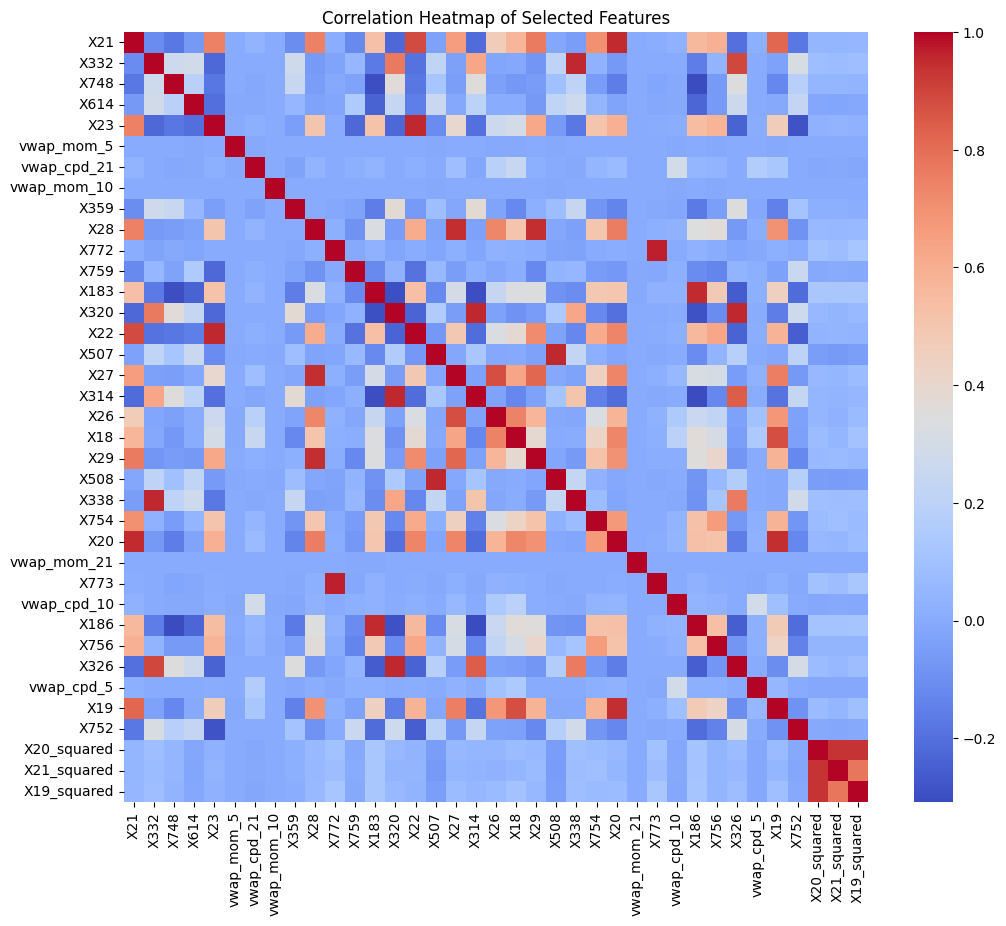

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix for selected features
corr_matrix = df_train[feature_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Selected Features')
plt.savefig('correlation_heatmap.png')
plt.show()